# Сессионное задание

**Описание**

Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий - группе аномальных или неидентифицируемых сигналов.
Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.


# 0 Импорты

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from google.colab import files


# 1 Первичный анализ

In [ ]:
df = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

In [ ]:
# cмотрим первые 5 строк датасета
df.head()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


In [ ]:
# смотрим размер датасета
df.shape

(23479, 505)

In [ ]:
# пропущенные значения
df.isnull().sum().sum()

np.int64(23479)

In [ ]:
# cтатистика по первым 5 столбцам
df.iloc[:, :5].describe().round(2)

,0,1,2,3,4
count,2.347900e+04,23479.00,23479.00,23479.0,23479.00
mean,1.009742e+11,869.16,372.19,500.0,14822.97
std,5.715472e+10,572.91,470.39,0.0,2.81
min,2.890276e+06,0.00,10.00,500.0,14812.00
25%,5.156311e+10,373.00,64.00,500.0,14821.00
50%,1.014553e+11,810.00,172.00,500.0,14823.00
75%,1.502418e+11,1341.00,483.00,500.0,14824.00
max,2.000107e+11,1998.00,3370.00,500.0,14834.00


**Вывод**

По первичному анализу выявлено, что датасет содержит 23479 сигналов по 505 столбцов. Столбцы 0, 1, 2, 3 это метаданные ФЭУ, они не несут информацию о форме сигнала и далее будут удалены. Столбец 504 содержит NaN и также будет удален. Остальные столбцы содержат запись сигналов. Далее будет более обширный EDA.

# 2 Предобработка

In [ ]:
# удаляем 0, 1, 2, 3 столбцы это метаданные ФЭУ и 504 столбец, тк он содержит NaN
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
print('Размер:', df.shape)

Размер: (23479, 500)


In [ ]:
# проверка
df.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [ ]:
raw = df.values.astype(float)

# выполняем инверсию
signals = 2**14 - raw - 1560

# формирование нулевой линии, среднее первых 50 отсчётов
baseline = signals[:, :50].mean(axis=1, keepdims=True)
signals -= baseline

print('Размер:', signals.shape)

Размер: (23479, 500)


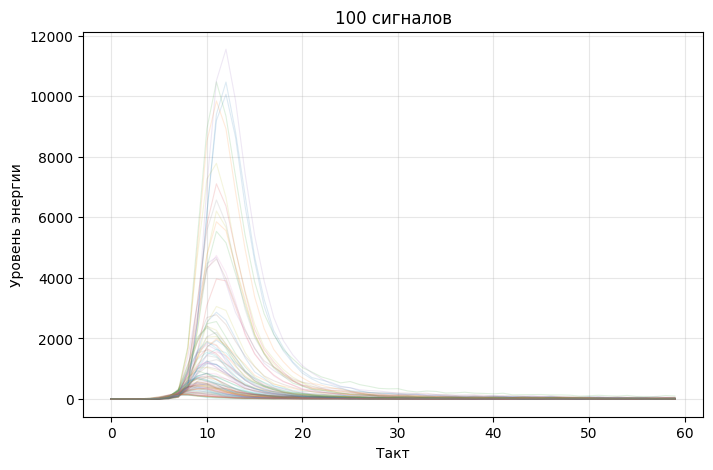

In [ ]:
# визуализация сигналов
plt.figure(figsize=(8, 5))
for s in signals[:100]:
    plt.plot(s[140:200], alpha=0.15, lw=0.8)
plt.title('100 сигналов')
plt.xlabel('Такт')
plt.ylabel('Уровень энергии')
plt.grid(alpha=0.3)
plt.show()

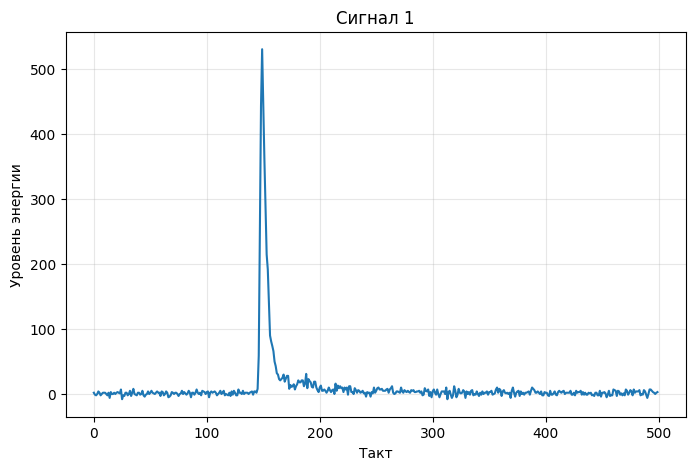

In [ ]:
# визуализация одного сигнала
plt.figure(figsize=(8, 5))
plt.plot(signals[0], lw=1.5)
plt.title('Сигнал 1')
plt.xlabel('Такт')
plt.ylabel('Уровень энергии')
plt.grid(alpha=0.3)
plt.show()

**Вывод**

В ходе предобработки удалены метаданные ФЭУ и столбец 504 содержащий NaN. Выполнена инверсия сигналов, то есть провалы АЦП теперь пики. Вычтена нулевая линия, которая представляет из себя среднее первых 50 тактов. Итого имеем 23479 сигналов по 500 тактов.

# 3 EDA после предобработки

In [ ]:
# пропущенные значения
df.isnull().sum().sum()

np.int64(0)

In [ ]:
# cтатистика по всему датасету
pd.Series(signals.ravel()).describe().round(2)

,0
count,11739500.00
mean,26.28
std,265.91
min,-15.60
25%,-0.90
50%,1.50
75%,4.52
max,14824.84


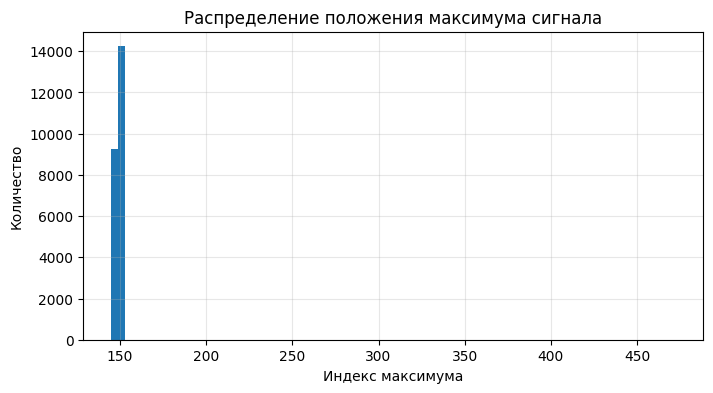

In [ ]:
# распределение положения максимума сигнала
peak_idx = signals.argmax(axis=1)
plt.figure(figsize=(8, 4))
plt.hist(peak_idx, bins=80)
plt.title('Распределение положения максимума сигнала')
plt.xlabel('Индекс максимума')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# статистика положения пиков сигнала
pd.Series(peak_idx).describe()

,0
count,23479.000000
mean,149.628604
std,2.489996
min,145.000000
25%,149.000000
50%,150.000000
75%,151.000000
max,472.000000


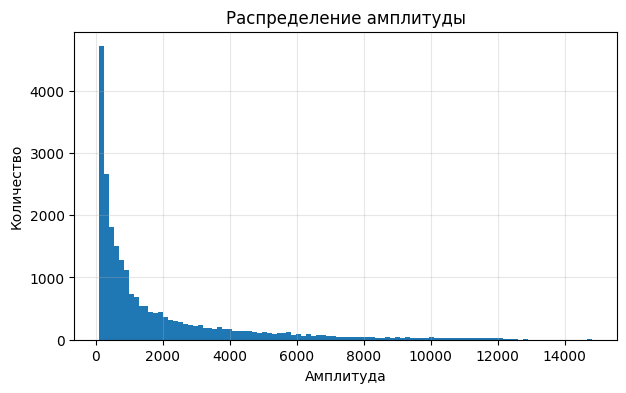

In [ ]:
# распределение амплитуды
amplitude_raw = signals.max(axis=1)
plt.figure(figsize=(7, 4))
plt.hist(amplitude_raw, bins=100)
plt.title('Распределение амплитуды')
plt.xlabel('Амплитуда')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()

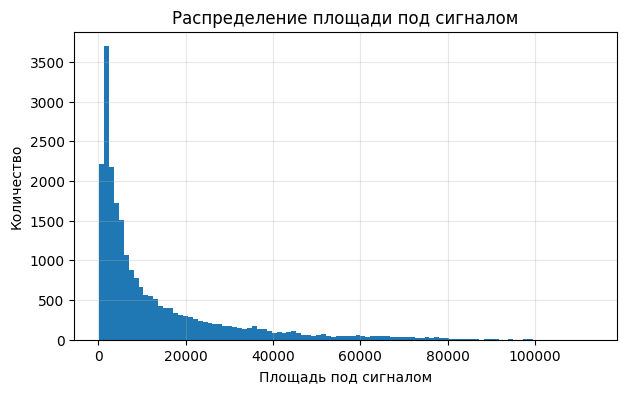

In [ ]:
# распределение площади под сигналом
volume_raw = signals.sum(axis=1)
plt.figure(figsize=(7, 4))
plt.hist(volume_raw, bins=100)
plt.title('Распределение площади под сигналом')
plt.xlabel('Площадь под сигналом')
plt.ylabel('Количество')
plt.grid(alpha=0.3)
plt.show()

**Вывод**

После предобработки пропущенных значений в данных не осталось. Статистика показывает, что основная часть значений находится около нулевой линии, при этом встречаются пики. Анализ положения максимумов показал, что большинство пиков расположено около 150го такта. Медиана равна 150, а основная часть значений находится в диапазоне 149 - 151. Большие значения могут соответствовать нетипичным сигналам или выбросам. Распределения амплитуды и площади под сигналом показывают неоднородность данных. Сигналы отличаются по форме и энергетическим характеристикам.

# 4 Feature Engineering

In [ ]:
def calc_features(signals, short_gate=35, long_gate=180, pre_peak=3):
    # количество сигналов и длина каждого сигнала
    n, m = signals.shape

    # основные характеристики сигнала
    amplitude = signals.max(axis=1) # амплитуда
    peak_idx = signals.argmax(axis=1) # положение максимума
    volume = signals.sum(axis=1) # площадь под сигналом

    # массивы для новых признаков
    short_area = np.zeros(n)
    long_area = np.zeros(n)
    tail_area = np.zeros(n)
    psd = np.zeros(n)

    # расчет площадей относительно пика сигнала
    for i, s in enumerate(signals):
        p = peak_idx[i]
        start = max(p - pre_peak, 0)

        # короткое и длинное окно после пика
        short = s[start:min(start + short_gate, m)].sum()
        long = s[start:min(start + long_gate, m)].sum()

        # площадь хвоста сигнала
        tail = long - short

        short_area[i] = short
        long_area[i] = long
        tail_area[i] = tail

        # PSD
        psd[i] = tail / (long + 1e-9)

    # итоговая таблица признаков
    features = pd.DataFrame({
        'amplitude': amplitude,
        'volume': volume,
        'log_amplitude': np.log1p(np.maximum(amplitude, 0)),
        'log_volume': np.log1p(np.maximum(volume, 0)),
        'peak_idx': peak_idx,
        'short_area': short_area,
        'long_area': long_area,
        'tail_area': tail_area,
        'psd': psd,
        'amp_over_volume': amplitude / (volume + 1e-9),
        'tail_over_short': tail_area / (short_area + 1e-9)
    })

    # замена возможных бесконечностей и пропусков
    return features.replace([np.inf, -np.inf], np.nan).fillna(0)

features = calc_features(signals)
features.head()

,amplitude,volume,log_amplitude,log_volume,peak_idx,short_area,long_area,tail_area,psd,amp_over_volume,tail_over_short
0,530.48,4789.0,6.275666,8.474286,149,3699.8,4472.4,772.6,0.172748,0.110771,0.208822
1,1901.48,12353.0,7.550914,9.421735,150,11530.8,12074.4,543.6,0.045021,0.153929,0.047143
2,2557.90,16945.0,7.847333,9.737787,151,15755.5,16380.0,624.5,0.038126,0.150953,0.039637
3,564.56,4558.0,6.337816,8.424859,149,3983.6,4479.8,496.2,0.110764,0.123861,0.124561
4,1793.60,11691.0,7.492537,9.366660,150,11139.0,11533.0,394.0,0.034163,0.153417,0.035371


In [ ]:
# статистика созданных признаков
features.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.105,2389.301,104.300,308.160,812.540,2315.050,14824.840
volume,23479.0,13141.392,16097.185,213.000,2447.000,6257.000,17291.000,113071.000
log_amplitude,23479.0,6.782,1.233,4.657,5.734,6.701,7.748,9.604
log_volume,23479.0,8.804,1.203,5.366,7.803,8.742,9.758,11.636
peak_idx,23479.0,149.629,2.490,145.000,149.000,150.000,151.000,472.000
short_area,23479.0,11940.802,14974.017,611.600,2136.950,5517.500,15427.550,107729.900
long_area,23479.0,12856.656,15817.031,516.600,2368.900,6077.200,16884.800,111804.200
tail_area,23479.0,915.855,1075.597,-224.900,189.150,498.900,1268.600,7671.600
psd,23479.0,0.083,0.055,-0.370,0.037,0.091,0.125,0.292
amp_over_volume,23479.0,0.135,0.029,0.060,0.112,0.131,0.157,0.611


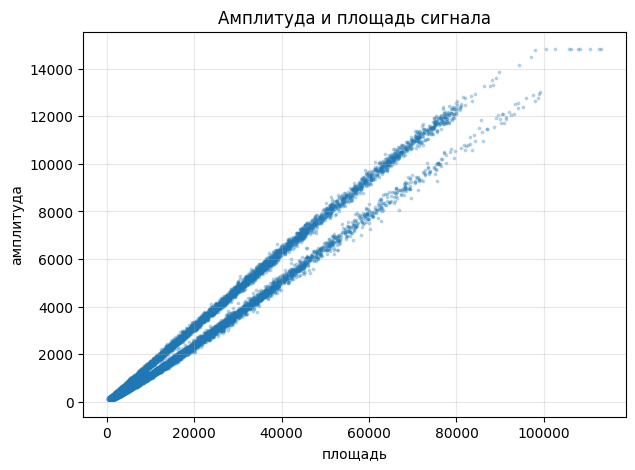

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(features['volume'], features['amplitude'], s=3, alpha=0.25)
plt.xlabel('площадь')
plt.ylabel('амплитуда')
plt.title('Амплитуда и площадь сигнала')
plt.grid(alpha=0.3)
plt.show()

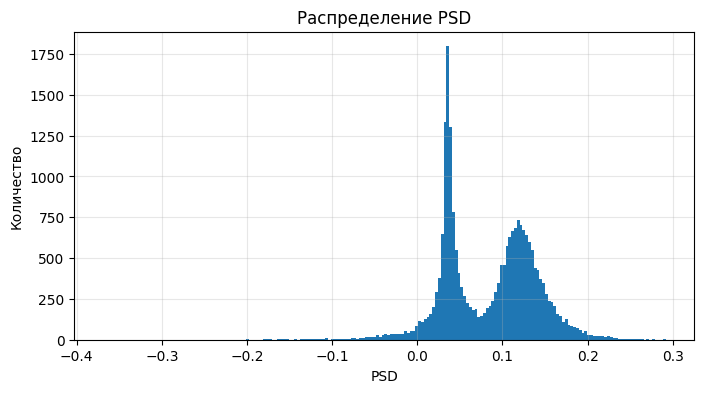

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(features['psd'], bins=200)
plt.xlabel('PSD')
plt.ylabel('Количество')
plt.title('Распределение PSD')
plt.grid(alpha=0.3)
plt.show()

**Вывод**

Для кластеризации были рассчитаны физически интерпретируемые признаки. Полученная таблица признаков далее будет использоваться для выбора финального набора признаков и обучения моделей.

# 5 Подбор и анализ признаков

Выбраны следующие признаки:
1) psd

Это главный признак формы сигнала. Он показывает, какая часть площади приходится на хвост.

2) log_volume

Это энергия или же площадь сигнала, но в сглаженном виде.

3) log_amplitude

Это амплитуда также в сглаженном виде.

4) amp_over_volume

Это отношение амплитуды к площади. Данный признак помогает отличать узкие и широкие импульсы.

5) tail_over_short

Это отношение хвоста к короткой части.

In [ ]:
# выбранные признаки
feature_cols = [
    'psd',
    'log_volume',
    'log_amplitude',
    'amp_over_volume',
    'tail_over_short'
]

# корреляция
features[feature_cols].corr().round(3)

,psd,log_volume,log_amplitude,amp_over_volume,tail_over_short
psd,1.000,-0.073,-0.224,-0.908,0.996
log_volume,-0.073,1.000,0.986,0.008,-0.105
log_amplitude,-0.224,0.986,1.000,0.171,-0.254
amp_over_volume,-0.908,0.008,0.171,1.000,-0.892
tail_over_short,0.996,-0.105,-0.254,-0.892,1.000


В финальную модель не были включены следующие признаки:

1) amplitude и volume

Вместо них взяты log_amplitude и log_volume соответственно. Логарифм уменьшает влияние слишком больших значений и выбросов и меньше зависит от масштаба сигнала.

2) peak_idx

Признак был полезен для EDA, но в модели может добавлять шум.

3) short_area

Информация о коротком участке уже учитывается через отношение tail_over_short.

4) long_area

Он связан с общей площадью сигнала и участвует в расчете psd.

5) tail_area

Хвостовая часть сигнала уже отражена в признаках psd и tail_over_short.

В финальный набор вошли только признаки, которые компактно описывают сигнал без лишнего дублирования.

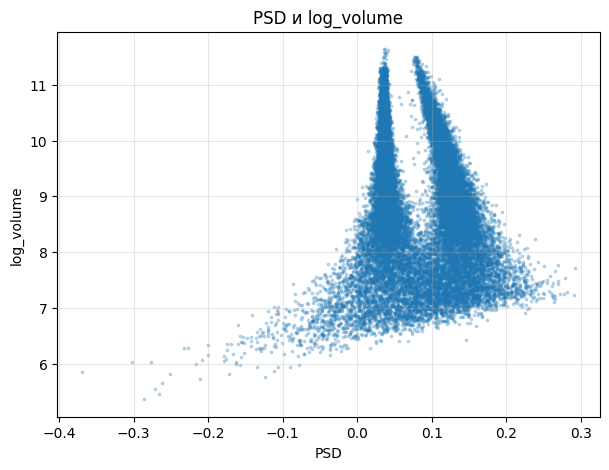

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(features['psd'], features['log_volume'], s=3, alpha=0.25)
plt.xlabel('PSD')
plt.ylabel('log_volume')
plt.title('PSD и log_volume')
plt.grid(alpha=0.3)
plt.show()

График PSD и log_volume показывает две выраженные зоны. Это подтверждает, что признаки формы сигнала и энергии могут быть полезны для дальнейшей кластеризации.

**Вывод**

Для дальнейшего обучения выбран набор признаков psd, log_volume, log_amplitude, amp_over_volume, tail_over_short. Эти признаки описывают форму импульса, энергию сигнала и вклад хвостовой части. Такой набор не перегружает модель и сохраняет физическую интерпретируемость. Несмотря на высокую корреляцию между psd и tail_over_short, оба признака были оставлены, так как они по разному нормируют хвостовую часть сигнала.

# 6 Обучение и сравнение моделей

In [ ]:
# копируем признаки для обучения
X = features[feature_cols].copy()

# масштабируем признаки
scaler = RobustScaler()
Z = scaler.fit_transform(X)

In [ ]:
# задаем модели для обучения
models = {
    'KMeans': KMeans(
        n_clusters=3,
        n_init=50,
        random_state=42
    ),
    'GMM': GaussianMixture(
        n_components=3,
        covariance_type='full',
        reg_covar=1e-4,
        n_init=50,
        random_state=42
    ),
    'BayesianGMM': BayesianGaussianMixture(
        n_components=3,
        covariance_type='full',
        reg_covar=1e-4,
        n_init=50,
        random_state=42
    )
}

In [ ]:
# список для сохранения результатов
results = []

# обучаем каждую модель и считаем метрики
for name, model in models.items():
    labels = model.fit_predict(Z)

    results.append({
        'model': name,
        'silhouette': silhouette_score(Z, labels),
        'davies_bouldin': davies_bouldin_score(Z, labels),
        'calinski_harabasz': calinski_harabasz_score(Z, labels),
        'cluster_sizes': dict(zip(*np.unique(labels, return_counts=True)))
    })

# смотрим результаты
pd.DataFrame(results)

,model,silhouette,davies_bouldin,calinski_harabasz,cluster_sizes
0,KMeans,0.433883,0.822659,21120.544405,"{0: 7160, 1: 6535, 2: 9784}"
1,GMM,0.389157,1.723957,8453.786271,"{0: 11297, 1: 1855, 2: 10327}"
2,BayesianGMM,0.388894,1.718962,8464.904024,"{0: 11310, 1: 10292, 2: 1877}"


**Вывод**

Были проверены три модели кластеризации KMeans, GMM и BayesianGMM. По внутренним метрикам лучший результат показал KMeans. У него выше silhouette и calinski_harabasz, а метрика davies_bouldin ниже. Но внутренние метрики оценивают только геометрическое качество кластеров. Для дальнейшей работы был выбран подход на основе GMM, так как эта модель позволяет не только разделить сигналы, но и получить вероятность принадлежности объекта к кластеру. Это поможет для последующего выделения третьего класса неопределенных сигналов.

# 7 Подбор гиперпараметров

По условию задачи два кластера это основные типы сигналов,
а третий кластер содержит аномальные или неидентифицируемые сигналы.
Поэтому финальную схему логичнее построить следующим образом:
1. GMM выделяет два основных кластера.
2. Объекты с низкой уверенностью модели относим к третьему кластеру.

7.1 Подбор гиперпараметров

In [ ]:
param_results = []

for cov_type in ['full', 'tied', 'diag']:
    for reg in [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]:
        model = GaussianMixture(
            n_components=2,
            covariance_type=cov_type,
            reg_covar=reg,
            n_init=50,
            random_state=42
        )

        labels = model.fit_predict(Z)

        param_results.append({
            'covariance_type': cov_type,
            'reg_covar': reg,
            'silhouette': silhouette_score(Z, labels),
            'davies_bouldin': davies_bouldin_score(Z, labels),
            'calinski_harabasz': calinski_harabasz_score(Z, labels),
            'cluster_sizes': dict(zip(*np.unique(labels, return_counts=True)))
        })

pd.DataFrame(param_results)

,covariance_type,reg_covar,silhouette,davies_bouldin,calinski_harabasz,cluster_sizes
0,full,0.000001,0.426320,0.979485,17831.389923,"{0: 11948, 1: 11531}"
1,full,0.000010,0.431817,0.968834,18322.229891,"{0: 12249, 1: 11230}"
2,full,0.000100,0.432000,0.968415,18343.943513,"{0: 12276, 1: 11203}"
3,full,0.001000,0.424610,0.982984,17665.193537,"{0: 11646, 1: 11833}"
4,full,0.010000,0.410891,1.009589,16492.324389,"{0: 12129, 1: 11350}"
5,tied,0.000001,0.421405,0.991156,17301.907293,"{0: 11832, 1: 11647}"
6,tied,0.000010,0.422968,0.987863,17442.102741,"{0: 11874, 1: 11605}"
7,tied,0.000100,0.428791,0.973465,18101.318972,"{0: 12029, 1: 11450}"
8,tied,0.001000,0.433108,0.963007,18583.966807,"{0: 12197, 1: 11282}"
9,tied,0.010000,0.433671,0.960912,18694.576226,"{0: 12294, 1: 11185}"


Хотя по внутренним метрикам лучший результат показали tied и diag, визуальный анализ показал, что эти варианты хуже отражают предположительную реальную структуру данных. В качестве финального варианта был выбран covariance_type='full'.

In [ ]:
# GMM выделяет два кластера сигналов
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    reg_covar=1e-4,
    n_init=50,
    random_state=42
)
raw_labels = gmm.fit_predict(Z)
proba = gmm.predict_proba(Z)

# максимальная вероятность показывает уверенность модели
confidence = proba.max(axis=1)

In [ ]:
# упорядочиваем два основных класса по PSD
temp = features.copy()
temp['raw_cluster'] = raw_labels
psd_stats = temp.groupby('raw_cluster')['psd'].median()
low_psd_raw = psd_stats.idxmin()
high_psd_raw = psd_stats.idxmax()
mapping = {low_psd_raw: 0, high_psd_raw: 1}
base_labels = pd.Series(raw_labels).map(mapping).to_numpy().astype(int)
pd.Series(base_labels).value_counts().sort_index()

,count
0,11203
1,12276


7.2 Подбор confidence_threshold

In [ ]:
# подбираем порог уверенности для выделения неопределенных сигналов
thresholds = [0.9, 0.8, 0.7, 0.6, 0.5]
tuning_results = []
for thr in thresholds:
    labels_tmp = base_labels.copy()
    labels_tmp[confidence < thr] = 2
    counts = pd.Series(labels_tmp).value_counts().sort_index().to_dict()
    tuning_results.append({
        'confidence_threshold': thr,
        'cluster_sizes': counts
    })
tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df

,confidence_threshold,cluster_sizes
0,0.9,"{0: 11032, 1: 12071, 2: 376}"
1,0.8,"{0: 11095, 1: 12155, 2: 229}"
2,0.7,"{0: 11143, 1: 12202, 2: 134}"
3,0.6,"{0: 11173, 1: 12246, 2: 60}"
4,0.5,"{0: 11203, 1: 12276}"


**Вывод**

В разделе был выполнен подбор гиперпараметров для GMM, а именно covariance_type, reg_covar и confidence_threshold. Внутренние метрики использовались как ориентир, но финальный выбор также учитывал интерпретируемость кластеров.

# 8 Выбор лучшей модели и объяснение выбора

In [ ]:
# финальная модель с выбранным порогом
confidence_threshold = 0.6
labels_final = base_labels.copy()
labels_final[confidence < confidence_threshold] = 2
pd.Series(labels_final).value_counts().sort_index()

,count
0,11173
1,12246
2,60


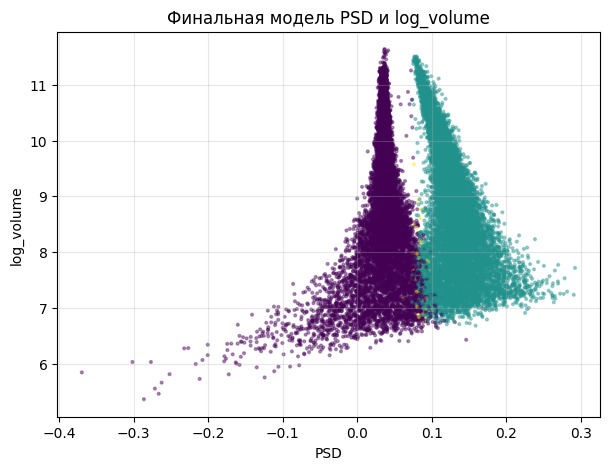

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(features['psd'], features['log_volume'], c=labels_final, s=4, alpha=0.4)
plt.xlabel('PSD')
plt.ylabel('log_volume')
plt.title('Финальная модель PSD и log_volume')
plt.grid(alpha=0.3)
plt.show()

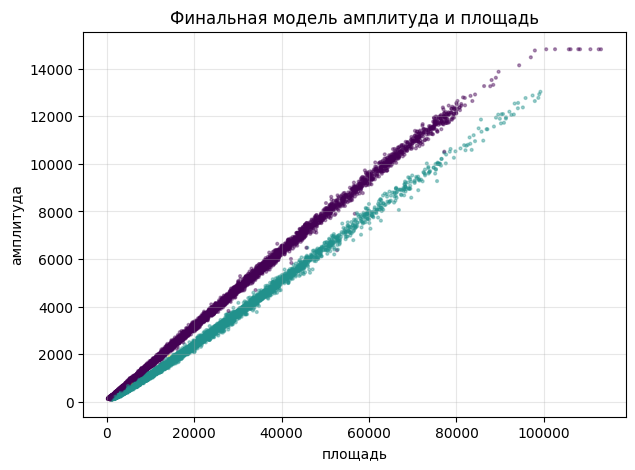

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(features['volume'], features['amplitude'], c=labels_final, s=4, alpha=0.4)
plt.xlabel('площадь')
plt.ylabel('амплитуда')
plt.title('Финальная модель амплитуда и площадь')
plt.grid(alpha=0.3)
plt.show()

**Вывод**

Финальная модель построена на GMM с двумя основными кластерами и дополнительным выделением аномальных сигналов по уверенности модели. В данном подходе сначала GMM формирует два кластера, а третий кластер составляет отсеянные сигналы через вероятностный подход.

# 9 Предсказание

In [ ]:
final_labels = labels_final.copy()
final_labels[labels_final == 0] = 1
final_labels[labels_final == 1] = 0
submission = pd.DataFrame({
    'index': np.arange(len(final_labels)),
    'cluster': final_labels
})

print(submission.shape)
submission.head()

(23479, 2)


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


In [ ]:
submission.to_csv('submission_final_.csv', index=False)

In [ ]:
files.download('submission_final_.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Итоговый вывод

В работе была решена задача кластеризации сигналов сцинтилляционного детектора на три кластера. После первичного анализа были удалены служебные столбцы и столбец с пропущенными значениями. Затем была выполнена инверсия сигнала и вычитание базовой линии.

Для кластеризации были рассчитаны физически интерпретируемые признаки: амплитуда, площадь под сигналом, PSD и признаки хвостовой части импульса. Были рассмотрены несколько моделей: KMeans, GaussianMixture и BayesianGaussianMixture.

Финальным решением стала схема GaussianMixture + порог вероятности. Она разделяет данные на два основных кластера, а объекты с низкой уверенностью модели относит к третьему кластеру.

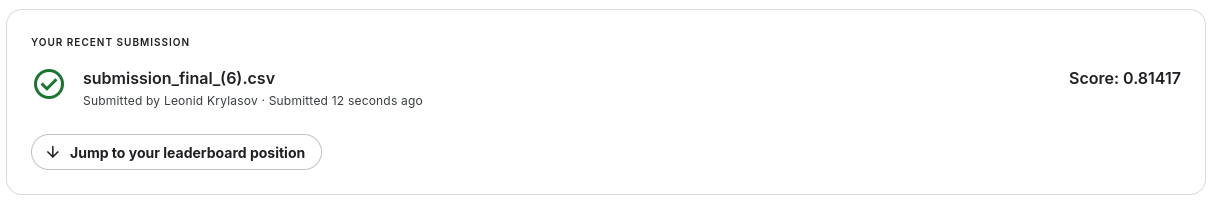